In [2]:
import pandas as pd

# Load the news dataset
# We use '../' because the notebook is in the 'notebooks' folder and data is in 'data/raw'
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv' , low_memory=False)

# Display the first few rows to make sure it loaded correctly
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
# 1. Get the length of each headline
df['headline_len'] = df['headline'].apply(len)

# 2. Display basic statistics for headline lengths
print("Headline Length Statistics:")
print(df['headline_len'].describe())

# 3. Count articles per publisher to see who is most active
publisher_counts = df['publisher'].value_counts()
print("\nTop 10 Most Active Publishers:")
print(publisher_counts.head(10))

Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

Top 10 Most Active Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


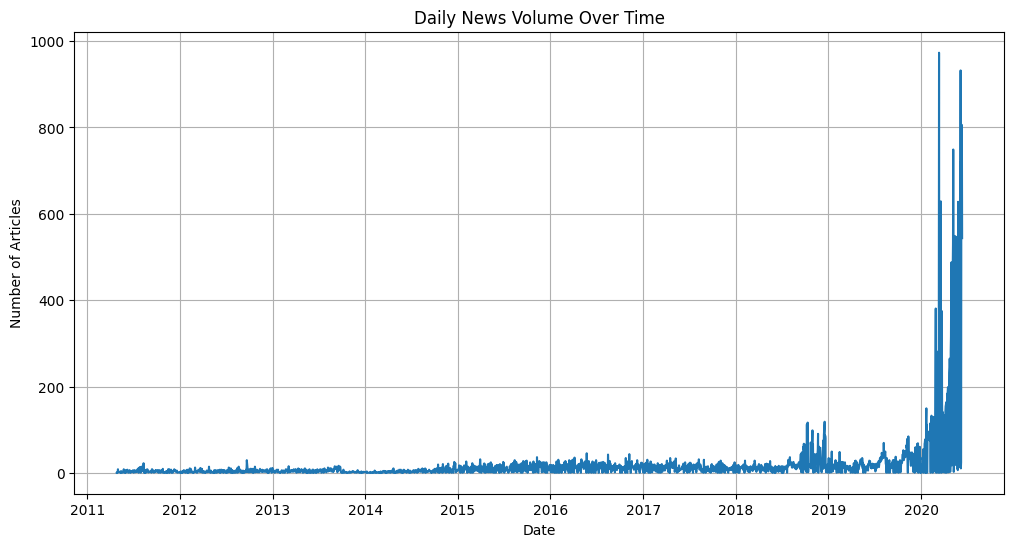

In [4]:
# 1. Convert the 'date' column to datetime objects
# We use errors='coerce' to handle any formatting issues
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Extract just the date (remove time) for daily grouping
df['only_date'] = df['date'].dt.date

# 3. Count articles per day and plot
daily_counts = df['only_date'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
daily_counts.plot(kind='line')
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize CountVectorizer to find common 2-word phrases (bigrams)
# stop_words='english' removes common words like 'the', 'and', etc.
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
X = vectorizer.fit_transform(df['headline'].dropna())

# 2. Get the phrases and their counts
phrases = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

# 3. Display the top recurring themes
print("Top 10 Recurring Themes in Headlines:")
for phrase, count in zip(phrases, counts):
    print(f"{phrase}: {count}")

Top 10 Recurring Themes in Headlines:
52 week: 51006
companies trading: 23170
earnings scheduled: 32055
initiates coverage: 28993
market update: 33101
mid day: 37324
pre market: 28393
price target: 47274
raises pt: 27213
stocks moving: 40044


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize CountVectorizer to find common 2-word phrases (bigrams)
# stop_words='english' removes common words like 'the', 'and', etc.
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
X = vectorizer.fit_transform(df['headline'].dropna())

# 2. Get the phrases and their counts
phrases = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

# 3. Display the top recurring themes
print("Top 10 Recurring Themes in Headlines:")
for phrase, count in zip(phrases, counts):
    print(f"{phrase}: {count}")

Top 10 Recurring Themes in Headlines:
52 week: 51006
companies trading: 23170
earnings scheduled: 32055
initiates coverage: 28993
market update: 33101
mid day: 37324
pre market: 28393
price target: 47274
raises pt: 27213
stocks moving: 40044
